## Modelowanie układów przepływowych - projekt  
#### (budowa solwera równań płytkiej wody na bazie pakietu PyMPDATA)
#### Jak ukształtowanie dna kontroluje, czy formuje się gwałtowny prąd wsteczny, czy też spokojny, szeroki odpływ?

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PyMPDATA-examples')

In [ ]:
import numpy as np
from matplotlib import pyplot
from open_atmos_jupyter_utils import show_plot, show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions
from PyMPDATA.boundary_conditions import Extrapolated

In [ ]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, uh_initial: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid) #klasa która odpowiada za wykonywanie kroków czasowych - kompilowane numbą, numeryczne kroki wykonaywane by uzyskać równanie adwekcji / adekcji - dyfuzji ; ,n_threads=1 - powoduje że wyłaczamy wielowątkowość
        kwargs = {
            'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid), #len(grid) - krotka wymiarów - przemnożone to znaczy że skopiowane 
            'halo': options.n_halo,
        } 
        advectees = {
            "h": ScalarField(h_initial, **kwargs), #**kwargs - trzy razy chcemy to samo przekazać więc robimy słownik argumentów funkcji i rozpakujemy go póżniej 
            "uh": ScalarField(uh_initial, **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField(( np.zeros((grid[X] + 1, grid[Y])), np.zeros((grid[X], grid[Y] + 1))), **kwargs ) #pole klasy - self.advector
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() } #generator - tworzymy nowy słownik - wygenerujemy 
        
    def __getitem__(self, key): # gdy wywołamy klase np a = A() to element a['coś '] - spowoduje że wywoła się ta funkcja i zwróci coś- ty element słownika   
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h'] - bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        # velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        # np.divide(momentum, self['h'], where=mask, out=velocity)
        velocity = np.zeros_like(momentum)
        np.divide(momentum, self['h'], out=velocity, where=mask)
        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)
        velocity_at_cell_boundaries = velocity[((all_but_last, all), (all, all_but_last),)[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[( (all_but_first_and_last, all), (all, all_but_first_and_last) )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        # assert np.amax(np.abs(courant_number)) <= 1
    # def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
    #     momentum = self[key]
    #     velocity = np.zeros_like(momentum)
    #     np.divide(momentum, self['h'], out=velocity, where=mask)
    #     velocity[~mask] = 0.0  # wymuszenie zera przy małej h
        
    #     all = slice(None)
    #     all_but_last = slice(None, -1)
    #     all_but_first_and_last = slice(1, -1)
        
    #     velocity_at_cell_boundaries = velocity[((all_but_last, all), (all, all_but_last))[axis]] + np.diff(velocity, axis=axis) / 2
    #     courant_number = self.advector.get_component(axis)[((all_but_first_and_last, all), (all, all_but_first_and_last))[axis]]
    #     courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
    #     courant_number[:] = np.clip(courant_number, -1.0, 1.0)  # zabezpieczenie

        

    # def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):  # definuiuje co się stanie jak wywołamy a() - przykładowo instancję klasy z okrągłym nawiasem 
    #     """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
    #     output = {k: [] for k in self.solvers.keys()}
    #     for it in range(nt + 1): 
    #         if it != 0:
    #             mask = self['h'] > eps
    #             for axis, key in enumerate(("uh", "vh")):
    #                 self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
    #             self.solvers["h"].advance(n_steps=1)
    #             for axis, key in enumerate(("uh", "vh")):
    #                 self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
    #                 self.solvers[key].advance(n_steps=1)
    #                 self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
    #         if it % outfreq == 0:
    #             for key in self.solvers.keys():
    #                 output[key].append(self[key].copy())
    #     return output
    def __call__(
        self, 
        *, 
        nt: int,                # liczba kroków czasowych
        g: float,               # przyspieszenie grawitacyjne
        dt_over_dxy: tuple,     # (dt/dx, dt/dy)
        outfreq: int,           # co ile kroków zapisywać dane
        eps: float = 1e-7       # próg, żeby unikać dzielenia przez zero
        ):
        """
        Integruje `nt` kroków czasowych i zwraca słownik stanów solvera,
        zapisywany co `outfreq` kroków czasowych.
        """
        # Przygotuj struktury na wyniki
        outputs = {name: [] for name in self.solvers.keys()}
        # -------------------------------------------------------------
        # Główna pętla czasowa
        # -------------------------------------------------------------
        for timestep in range(nt + 1):
            # ---------------------------------------------------------
            # POMIJAMY krok 0 — to jest stan początkowy
            # ---------------------------------------------------------
            if timestep != 0:
                # Maska: tylko tam, gdzie głębokość > eps
                valid_cells = self['h'] > eps
                # -----------------------------------------------------
                # 1. Aktualizacja liczb Couranta (osie X i Y)
                # -----------------------------------------------------
                velocity_keys = ("uh", "vh")
                for axis, field_name in enumerate(velocity_keys):
                    self._update_courant_numbers(
                        axis=axis,
                        key=field_name,
                        mask=valid_cells,
                        dt_over_dxy=dt_over_dxy
                    )
                # -----------------------------------------------------
                # 2. Kroki solvera dla wysokości wody h
                # -----------------------------------------------------
                self.solvers["h"].advance(n_steps=1)
                # -----------------------------------------------------
                # 3. Kroki solverów dla pędu (uh i vh)
                # -----------------------------------------------------
                for axis, field_name in enumerate(velocity_keys):
                    # 3a. Połowa prawej strony równania (half RHS step)
                    self._apply_half_rhs(
                        key=field_name,
                        axis=axis,
                        g_times_dt_over_dxy=g * dt_over_dxy[axis]
                    )
                    # 3b. Aktualizacja solvera pędu o jeden krok
                    self.solvers[field_name].advance(n_steps=1)
                    # 3c. Druga połowa RHS (symetrycznie)
                    self._apply_half_rhs(
                        key=field_name,
                        axis=axis,
                        g_times_dt_over_dxy=g * dt_over_dxy[axis]
                    )
            # ---------------------------------------------------------
            # ZAPIS stanu do wyników co outfreq kroków
            # ---------------------------------------------------------
            if timestep % outfreq == 0:
                for field_name in self.solvers.keys():
                    outputs[field_name].append(self[field_name].copy())
        # Zwracamy słownik list: h, uh, vh zapisane w czasie
        return outputs
grid = (60, 50)
# grid = (120, 80)
bathymetry = np.tile(np.linspace(0,3,grid[1]),(grid[0],1)) #dno delta dzeta
# depth_max = 1.0     # głęboka woda
# slope = 0.02        # nachylenie plaży
# # bathymetry = slope * np.arange(grid[1])[None, :]  

# Głęboki ocean po prawej, płytko po lewej
max_depth = 2.0
slope = 0.03

# bathymetry =np.tile( max_depth - slope * np.arange(grid[1]),(grid[0],1))
# bathymetry[bathymetry < 0] = 0  # brzeg
h_initial = bathymetry.copy() #np.ones(grid, dtype=float)
Y = np.arange(grid[1])
wave_center = 40
wave_width = 4
wave_height = 0.3

# h_initial += wave_height * np.exp(-((Y - wave_center)**2) / (2 * wave_width**2))[None, :]

h_initial[
    grid[0] // 2 - grid[0] // 20 : grid[0] // 2 + grid[0] // 20,
    grid[1] // 2 - grid[1] // 20 : grid[1] // 2 + grid[1] // 20 
    # 0:grid[0],0: grid[1]//2
    #5:45,0:40 +=0.25 (x,y) 
] +=.025

# uh_initial = np.zeros(grid)
# uh_initial[:, :] = 0.5 
output = ShallowWaterEquationsIntegrator(h_initial=h_initial,uh_initial=np.zeros(h_initial.shape))(nt=100, g=10, dt_over_dxy=(0.25, 0.25), outfreq=3) #- pierwszy nawias tworzy element klasy a drugi wywołuje __call__ z tymi parametrami


KeyboardInterrupt: 

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

colors = [
    (0.95, 0.85, 0.60),  # beach sand – jasny beż
    (0.70, 0.90, 1.00),  # shallow water – turkus
    (0.00, 0.30, 0.60),  # deep ocean – ciemny niebieski
]

beach_cmap = LinearSegmentedColormap.from_list("beach", colors)


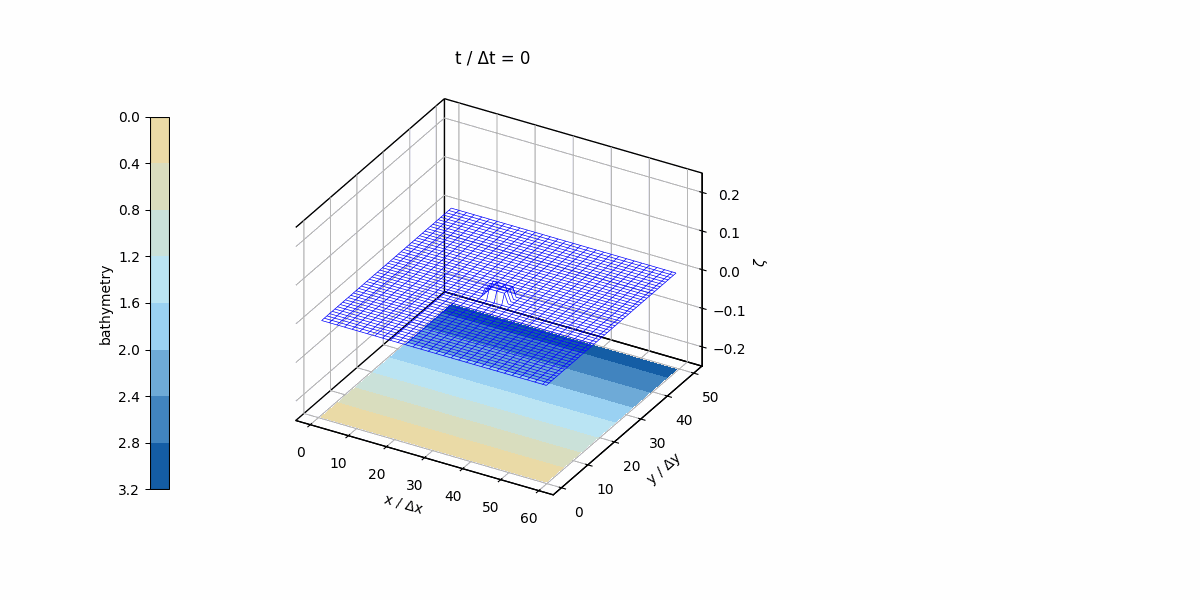

HTML(value="<a href='.\\tmprshd398t.gif' target='_blank'>.\\tmprshd398t.gif</a><br>")

In [ ]:
def plot(frame, *, zlim=(-0.25, 0.25)):
    psi = output['h'][frame]-bathymetry
    xi, yi = np.indices(psi.shape) #indeksy 
    fig, ax = pyplot.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 6))
    ax.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)
    ax.set(zlim=zlim, proj_type='ortho', title=f"t / Δt = {frame}", zlabel=r"$\zeta$")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('black')
        axis.pane.set_alpha(1)
    for axis in ('x', 'y'):
        getattr(ax, f'set_{axis}label')(f"{axis} / Δ{axis}")
    pyplot.colorbar(
        ax.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=zlim[0],cmap=beach_cmap),#cmap = 'ocean'
        pad=.1, aspect=20, fraction=.02, label='bathymetry', location='left'
    ).ax.invert_yaxis()
    return fig
show_anim(plot, range(len(output['h'])))

In [ ]:
class ShallowWaterSolver:
    def __init__(self,*,h_initial:np.ndarray,options:Options=None):
        options = options or Options(nonoscillatory=True,infinite_gauge=True)  
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid,n_threads=1) 
        kwargs = {
            'boundary_conditions': [boundary_conditions.Extrapolated()] * len(grid), #len(grid) - krotka wymiarów - przemnożone to znaczy że skopiowane 
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs), #**kwargs - trzy razy chcemy to samo przekazać więc robimy słownik argumentów funkcji i rozpakujemy go póżniej 
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }

    def __call__(
        self, 
        *, 
        nt: int,                # liczba kroków czasowych
        g: float,               # przyspieszenie grawitacyjne
        dt_over_dxy: tuple,     # (dt/dx, dt/dy)
        outfreq: int,           # co ile kroków zapisywać dane
        eps: float = 1e-7       # próg, żeby unikać dzielenia przez zero
        ):
        """
        Integruje `nt` kroków czasowych i zwraca słownik stanów solvera,
        zapisywany co `outfreq` kroków czasowych.
        """
        # Przygotuj struktury na wyniki
        outputs = {name: [] for name in self.solvers.keys()}
        # -------------------------------------------------------------
        # Główna pętla czasowa
        # -------------------------------------------------------------
        for timestep in range(nt + 1):
            # ---------------------------------------------------------
            # POMIJAMY krok 0 — to jest stan początkowy
            # ---------------------------------------------------------
            if timestep != 0:
                # Maska: tylko tam, gdzie głębokość > eps
                valid_cells = self['h'] > eps
                # -----------------------------------------------------
                # 1. Aktualizacja liczb Couranta (osie X i Y)
                # -----------------------------------------------------
                velocity_keys = ("uh", "vh")
                for axis, field_name in enumerate(velocity_keys):
                    self._update_courant_numbers(
                        axis=axis,
                        key=field_name,
                        mask=valid_cells,
                        dt_over_dxy=dt_over_dxy
                    )
                # -----------------------------------------------------
                # 2. Kroki solvera dla wysokości wody h
                # -----------------------------------------------------
                self.solvers["h"].advance(n_steps=1)
                # -----------------------------------------------------
                # 3. Kroki solverów dla pędu (uh i vh)
                # -----------------------------------------------------
                for axis, field_name in enumerate(velocity_keys):
                    # 3a. Połowa prawej strony równania (half RHS step)
                    self._apply_half_rhs(
                        key=field_name,
                        axis=axis,
                        g_times_dt_over_dxy=g * dt_over_dxy[axis]
                    )
                    # 3b. Aktualizacja solvera pędu o jeden krok
                    self.solvers[field_name].advance(n_steps=1)
                    # 3c. Druga połowa RHS (symetrycznie)
                    self._apply_half_rhs(
                        key=field_name,
                        axis=axis,
                        g_times_dt_over_dxy=g * dt_over_dxy[axis]
                    )
            # ---------------------------------------------------------
            # ZAPIS stanu do wyników co outfreq kroków
            # ---------------------------------------------------------
            if timestep % outfreq == 0:
                for field_name in self.solvers.keys():
                    outputs[field_name].append(self[field_name].copy())
        # Zwracamy słownik list: h, uh, vh zapisane w czasie
        return outputs


C:\Users\nkurd\AppData\Local\Temp\ipykernel_30320\1229458862.py:22: RuntimeWarning: invalid value encountered in sqrt
  c = np.sqrt(g*h)
C:\Users\nkurd\AppData\Local\Temp\ipykernel_30320\1229458862.py:25: RuntimeWarning: divide by zero encountered in divide
  eta_shoal = eta * np.sqrt(h0/h)
C:\Users\nkurd\AppData\Local\Temp\ipykernel_30320\1229458862.py:25: RuntimeWarning: invalid value encountered in sqrt
  eta_shoal = eta * np.sqrt(h0/h)


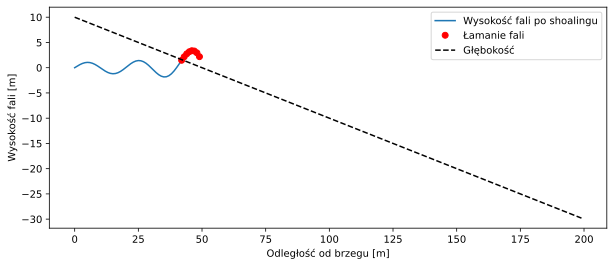

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry
g = 9.81  # m/s²
dx = 1.0  # krok przestrzenny [m]
dt = 0.1  # krok czasowy [s]
L = 200   # długość akwenu [m]
x = np.arange(0, L, dx)

# Głębokość zmienia się przy brzegu
h0 = 10.0   # głębokość na początku [m]
h = h0 - (h0/50) * x  # liniowe spłycanie do brzegu

# Fala początkowa
H0 = 1.0  # wysokość fali [m]
lambda0 = 20.0  # długość fali [m]
k = 2*np.pi/lambda0
eta = H0 * np.sin(k * x)

# Prędkość fali
c = np.sqrt(g*h)

# Shoaling – wzrost wysokości fali
eta_shoal = eta * np.sqrt(h0/h)

# Kryterium łamania
breaking = eta_shoal / h > 0.78

# Wizualizacja
plt.figure(figsize=(10,4))
plt.plot(x, eta_shoal, label="Wysokość fali po shoalingu")
plt.plot(x[breaking], eta_shoal[breaking], 'ro', label="Łamanie fali")
plt.plot(x, h, 'k--', label="Głębokość")
plt.xlabel("Odległość od brzegu [m]")
plt.ylabel("Wysokość fali [m]")
plt.legend()
plt.show()


In [ ]:
def plot(frame, *, zlim=(-0.25, 0.25)):
    psi = output['h'][frame]-bathymetry
    xi, yi = np.indices(psi.shape)
    fig, ax = pyplot.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 6))
    ax.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)
    ax.set(zlim=zlim, proj_type='ortho', title=f"t / Δt = {frame}", zlabel=r"$\zeta$")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('black')
        axis.pane.set_alpha(1)
    for axis in ('x', 'y'):
        getattr(ax, f'set_{axis}label')(f"{axis} / Δ{axis}")
    pyplot.colorbar(
        ax.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=zlim[0],cmap=beach_cmap),
        pad=.1, aspect=10, fraction=.02, label='bathymetry', location='left'
    ).ax.invert_yaxis()
    return fig

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

colors = [
    (0.95, 0.85, 0.60),  # beach sand – jasny beż
    (0.70, 0.90, 1.00),  # shallow water – turkus
    (0.00, 0.30, 0.60),  # deep ocean – ciemny niebieski
]

beach_cmap = LinearSegmentedColormap.from_list("beach", colors)


In [ ]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid,n_threads=1) #klasa która odpowiada za wykonywanie kroków czasowych - kompilowane numbą, numeryczne kroki wykonaywane by uzyskać równanie adwekcji / adekcji - dyfuzji ; ,n_threads=1 - powoduje że wyłaczamy wielowątkowość
        # kwargs = {
        #     'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid), #len(grid) - krotka wymiarów - przemnożone to znaczy że skopiowane 
        #     'halo': options.n_halo,
        # } 
        kwargs = {
            'boundary_conditions': [
                boundary_conditions.Extrapolated(),
                boundary_conditions.Extrapolated()
            ],
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs), #**kwargs - trzy razy chcemy to samo przekazać więc robimy słownik argumentów funkcji i rozpakujemy go póżniej 
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((  #pole klasy - self.advector
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() } #generator - tworzymy nowy słownik - wygenerujemy 

    def __getitem__(self, key): # gdy wywołamy klase np a = A() to element a['coś '] - spowoduje że wywoła się ta funkcja i zwróci coś- ty element słownika   
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    # def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
    #     """ applies half of the source term in the given direction """
    #     self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']- bathymetry, axis=axis)
    
    # def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
    #     # g ∂x ζ
    #     grad = np.gradient(self['h'] - bathymetry, axis=axis)
    #     self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * grad
    #     # ======== NOWOŚĆ: DYSSYPACJA W RUN-UP / BREAKING ========
    #     if key in ('uh','vh'):
    #         u = self['uh'] / self['h']
    #         v = self['vh'] / self['h']
    #         speed = np.sqrt(u**2 + v**2)
    #         # kryterium łamania
    #         eta = self['h'] - bathymetry
    #         breaking = (eta / self['h']) > 0.78
    #         # lokalna stała dyssypacji
    #         cd_local = 0.05 * (1 + 20*breaking)
    #         # źródło oporu: - c_d h |u| u
    #         friction = cd_local * self['h'] * speed
    #         if axis == 0:
    #             self[key][:] -= .5 * friction * u
    #         else:
    #             self[key][:] -= .5 * friction * v
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        # --- hydrodynamiczna siła ciśnienia: -gh ∂x ζ ---
        grad = np.gradient(self['h'] - bathymetry, axis=axis)
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * grad
        
        # --- tylko dla równań pędu (uh, vh) ---
        if key in ('uh','vh'):
            h = self['h']
            u = self['uh'] / h
            v = self['vh'] / h
            speed = np.sqrt(u**2 + v**2)

            # wysokość powierzchni
            eta = h - bathymetry

            # kryterium łamania fali Michea
            breaking = eta > 0.78 * h

            # współczynnik tarcia dna (zwiększany tam, gdzie fala łamie się)
            cd = 0.015
            cd_local = cd * (1 + 25 * breaking)

            # tarcie -cd * h * |u| u
            if axis == 0:
                self[key][:] -= .5 * cd_local * h * speed * u
            else:
                self[key][:] -= .5 * cd_local * h * speed * v




    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        assert np.amax(np.abs(courant_number)) <= 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):  # definuiuje co się stanie jak wywołamy a() - przykładowo instancję klasy z okrągłym nawiasem 
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output
   

In [ ]:
# grid = (50, 40)
# bathymetry = np.tile(np.linspace(0,2,grid[1]),(grid[0],1)) #dno delta dzeta
# h_initial = bathymetry.copy() #np.ones(grid, dtype=float)
# h_initial[
#     grid[0] // 2 - grid[0] // 20:
#     grid[0] // 2 + grid[0] // 20,
#     grid[1] // 2 - grid[1] // 20:
#     grid[1] // 2 + grid[1] // 20
# ] += .025*3
# output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(nt=200, g=10, dt_over_dxy=(.25, .25), outfreq=3) #- pierwszy nawias tworzy element klasy a drugi wywołuje __call__ z tymi parametrami
# show_anim(plot, range(len(output['h'])))


In [ ]:
# # Plaża o nachyleniu ~3% (zmieniaj slope aby sterować stromością)
# slope = 0.03

# # x – kierunek od oceanu ku brzegowi
# x = np.linspace(0, grid[1]-1, grid[1])
# b_profile = 0.1 + slope * x   # ocean po lewej, brzeg po prawej

# bathymetry = np.tile(b_profile, (grid[0], 1))
# h_initial = bathymetry.copy()

# # Centralna górka fali jako gauss (tsunami-like)
# X, Y = np.meshgrid(np.arange(grid[0]), np.arange(grid[1]), indexing='ij')

# x0 = grid[0]//2       # po środku
# y0 = grid[1]//4       # na głębokiej wodzie (lewa strona)
# R = 6                 # szerokość impulsu

# eta0 = 0.15           # amplituda impulsu
# h_initial += eta0 * np.exp(-((X - x0)**2 + (Y - y0)**2)/R**2)
# output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(nt=200, g=10, dt_over_dxy=(.25, .25), outfreq=3) #- pierwszy nawias tworzy element klasy a drugi wywołuje __call__ z tymi parametrami
# show_anim(plot, range(len(output['h'])))


In [ ]:
# # parametry plaży
# slope = 0.03
# x = np.linspace(0, grid[1]-1, grid[1])
# base = 0.1 + slope * x  # podstawowy stok
# # falistość – powolnie zmienna
# waves = 0.05 * np.sin(0.2 * x) + 0.03 * np.sin(0.5 * x + 1.5)
# # "perlin-like" szum płynny (filtrujemy szum losowy)
# raw_noise = np.random.randn(grid[1]) * 0.05
# smooth_noise = np.convolve(raw_noise, np.ones(5)/5, mode='same')
# # SUMA – gotowa batymetria
# b_profile = base + waves + smooth_noise
# bathymetry = np.tile(b_profile, (grid[0], 1))
# output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(nt=200, g=10, dt_over_dxy=(.25, .25), outfreq=3) #- pierwszy nawias tworzy element klasy a drugi wywołuje __call__ z tymi parametrami
# show_anim(plot, range(len(output['h'])))


In [ ]:

# # # Centralna górka fali jako gauss (tsunami-like)
# # X, Y = np.meshgrid(np.arange(grid[0]), np.arange(grid[1]), indexing='ij')

# # x0 = grid[0]//2       # po środku
# # y0 = grid[1]//4       # na głębokiej wodzie (lewa strona)
# # R = 6                 # szerokość impulsu

# # eta0 = 0.15           # amplituda impulsu
# # h_initial += eta0 * np.exp(-((X - x0)**2 + (Y - y0)**2)/R**2)
# h_initial = bathymetry.copy()

# # fala wysoka na całą szerokość y
# x = np.arange(grid[1])
# x0 = 10           # odległość początkowa od brzegu
# width = 5         # szerokość fali
# amplitude = 0.15  # wysokość fali

# # fala typu "górka" wzdłuż y:
# profile = amplitude * np.exp(-((x - x0)**2) / width**2)

# # kopiujemy profil na całą szerokość y
# h_initial += np.tile(profile, (grid[0], 1))
# output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(nt=200, g=10, dt_over_dxy=(.25, .25), outfreq=3) #- pierwszy nawias tworzy element klasy a drugi wywołuje __call__ z tymi parametrami
# show_anim(plot, range(len(output['h'])))


In [ ]:
# # ---------------------------
# # 2D batymetria dla rip current
# # ---------------------------
# grid = (50, 40)

# nx, ny = grid  # = (50, 40)
# x0 = 10           # odległość początkowa od brzegu
# width = 5         # szerokość fali
# amplitude = 0.15 


# # x – od oceanu do brzegu
# x = np.linspace(0, 1, ny)
# # y – wzdłuż brzegu
# y = np.linspace(-1, 1, nx)

# X, Y = np.meshgrid(x, y)

# # bazowy stok plaży
# slope = 0.03
# base = 0.1 + slope * (x * ny)
# base = np.tile(base, (nx,1))

# # kanał ripowy (głębszy w środku)
# channel = -0.25 * np.exp(-(Y**2) / 0.15)

# # łachy piasku po bokach (sandbars)
# bars = 0.12 * np.exp(-((Y-0.7)**2)/0.06) + 0.12 * np.exp(-((Y+0.7)**2)/0.06)

# # końcowa batymetria
# bathymetry = base + channel + bars

# # zapobiegamy wartościom ujemnym
# bathymetry = np.maximum(bathymetry, 0.05)

# # fala na całej szerokości, lekko modulowana wzdłuż brzegu
# wave = amplitude * np.exp(-((x - x0)**2) / width**2)

# modulation = 1 + 0.1 * np.cos(2 * np.pi * (y[:,None] + np.random.rand()))

# h_initial = bathymetry + wave * modulation



# output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(nt=200, g=10, dt_over_dxy=(.25, .25), outfreq=3) #- pierwszy nawias tworzy element klasy a drugi wywołuje __call__ z tymi parametrami

# show_anim(plot, range(len(output['h'])))


AssertionError: 

In [ ]:
# # === GRID MUSI BYĆ ZDEFINIOWANY PIERWSZY ===
# grid = (50, 40)
# nx, ny = grid

# # ---------------------------------------
# # 2D BATYMETRIA Z RIP CURRENT
# # ---------------------------------------

# # x – od oceanu (0) do brzegu (1)
# x = np.linspace(0, 1, ny)
# # y – wzdłuż brzegu
# y = np.linspace(-1, 1, nx)

# X, Y = np.meshgrid(x, y)

# # bazowy stok plaży
# slope = 0.03
# base = 0.1 + slope * (x * ny)
# base = np.tile(base, (nx,1))

# # kanał ripowy (głębszy środek)
# channel = -0.25 * np.exp(-(Y**2) / 0.15)

# # łachy piasku po bokach
# bars = (
#     0.12 * np.exp(-((Y-0.7)**2)/0.06) +
#     0.12 * np.exp(-((Y+0.7)**2)/0.06)
# )

# # finalna batymetria
# bathymetry = base + channel + bars

# # nie pozwalamy, żeby głębokość była < 0
# bathymetry = np.maximum(bathymetry, 0.05)

# # ---------------------------------------
# # POCZĄTKOWA FALA NA CAŁEJ SZEROKOŚCI
# # ---------------------------------------

# amplitude = 0.15
# x0 = 0.15
# width = 0.05

# wave = amplitude * np.exp(-((x - x0)**2) / width**2)

# # modulacja wzdłuż brzegu (realistyczna nieregularność)
# modulation = 1 + 0.1 * np.cos(2 * np.pi * (y[:,None] + np.random.rand()))

# # h_initial = batymetria + wysokość fali
# h_initial = bathymetry + wave * modulation
# output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(nt=200, g=10, dt_over_dxy=(.25, .25), outfreq=3) #- pierwszy nawias tworzy element klasy a drugi wywołuje __call__ z tymi parametrami

# show_anim(plot, range(len(output['h'])))

AssertionError: 

In [4]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial: np.ndarray, options: Options = None):
        """ initializes the solvers for a given initial condition of `h` assuming zero momenta at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        stepper = Stepper(options=options, grid=grid,n_threads=1) #klasa która odpowiada za wykonywanie kroków czasowych - kompilowane numbą, numeryczne kroki wykonaywane by uzyskać równanie adwekcji / adekcji - dyfuzji ; ,n_threads=1 - powoduje że wyłaczamy wielowątkowość
        # kwargs = {
        #     'boundary_conditions': [boundary_conditions.Constant(value=0)] * len(grid), #len(grid) - krotka wymiarów - przemnożone to znaczy że skopiowane 
        #     'halo': options.n_halo,
        # } 
        kwargs = {
            'boundary_conditions': [
                boundary_conditions.Extrapolated(),
                boundary_conditions.Extrapolated()
            ],
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs), #**kwargs - trzy razy chcemy to samo przekazać więc robimy słownik argumentów funkcji i rozpakujemy go póżniej 
            "uh": ScalarField(np.zeros(grid), **kwargs),
            "vh": ScalarField(np.zeros(grid), **kwargs),
        }
        self.advector = VectorField((  #pole klasy - self.advector
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() } #generator - tworzymy nowy słownik - wygenerujemy 

    def __getitem__(self, key): # gdy wywołamy klase np a = A() to element a['coś '] - spowoduje że wywoła się ta funkcja i zwróci coś- ty element słownika   
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    # def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
    #     """ applies half of the source term in the given direction """
    #     self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']- bathymetry, axis=axis)
    
    # def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
    #     # g ∂x ζ
    #     grad = np.gradient(self['h'] - bathymetry, axis=axis)
    #     self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * grad
    #     # ======== NOWOŚĆ: DYSSYPACJA W RUN-UP / BREAKING ========
    #     if key in ('uh','vh'):
    #         u = self['uh'] / self['h']
    #         v = self['vh'] / self['h']
    #         speed = np.sqrt(u**2 + v**2)
    #         # kryterium łamania
    #         eta = self['h'] - bathymetry
    #         breaking = (eta / self['h']) > 0.78
    #         # lokalna stała dyssypacji
    #         cd_local = 0.05 * (1 + 20*breaking)
    #         # źródło oporu: - c_d h |u| u
    #         friction = cd_local * self['h'] * speed
    #         if axis == 0:
    #             self[key][:] -= .5 * friction * u
    #         else:
    #             self[key][:] -= .5 * friction * v
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        # --- hydrodynamiczna siła ciśnienia: -gh ∂x ζ ---
        grad = np.gradient(self['h'] - bathymetry, axis=axis)
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * grad
        
        # --- tylko dla równań pędu (uh, vh) ---
        if key in ('uh','vh'):
            h = self['h']
            u = self['uh'] / h
            v = self['vh'] / h
            speed = np.sqrt(u**2 + v**2)

            # wysokość powierzchni
            eta = h - bathymetry

            # kryterium łamania fali Michea
            breaking = eta > 0.78 * h

            # współczynnik tarcia dna (zwiększany tam, gdzie fala łamie się)
            cd = 0.015
            cd_local = cd * (1 + 25 * breaking)
            self[key][:] *= 0.995  # mała dyssypacja

            # tarcie -cd * h * |u| u
            if axis == 0:
                self[key][:] -= .5 * cd_local * h * speed * u
            else:
                self[key][:] -= .5 * cd_local * h * speed * v




    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        # using slices to ensure views (over copies)
        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        # courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        # assert np.amax(np.abs(courant_number)) <= 1
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        max_c = np.nanmax(np.abs(courant_number))
        if max_c > 1:
            print(f"UWAGA: max Courant = {max_c:.2f}")
            # assert max_c <= 1  # możesz na chwilę zakomentować


    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):  # definuiuje co się stanie jak wywołamy a() - przykładowo instancję klasy z okrągłym nawiasem 
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1): 
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                # tłumienie przy brzegu
                beach_zone = 8
                damping = np.linspace(0, 1, beach_zone)**2  # rośnie ku brzegowi
                self['uh'][:, -beach_zone:] *= (1 - damping)
                self['vh'][:, -beach_zone:] *= (1 - damping)
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output
   

In [6]:
from matplotlib.colors import LinearSegmentedColormap

colors = [
    (0.95, 0.85, 0.60),  # beach sand – jasny beż
    (0.70, 0.90, 1.00),  # shallow water – turkus
    (0.00, 0.30, 0.60),  # deep ocean – ciemny niebieski
]

beach_cmap = LinearSegmentedColormap.from_list("beach", colors)
def plot(frame, *, zlim=(-0.25, 0.25)):
    psi = output['h'][frame]-bathymetry
    xi, yi = np.indices(psi.shape)
    fig, ax = pyplot.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 6))
    ax.plot_wireframe(xi+.5, yi+.5, psi, color='blue', linewidth=.5)
    ax.set(zlim=zlim, proj_type='ortho', title=f"t / Δt = {frame}", zlabel=r"$\zeta$")
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor('black')
        axis.pane.set_alpha(1)
    for axis in ('x', 'y'):
        getattr(ax, f'set_{axis}label')(f"{axis} / Δ{axis}")
    pyplot.colorbar(
        ax.contourf(xi+.5, yi+.5, bathymetry, zdir='z', offset=zlim[0],cmap=beach_cmap),
        pad=.1, aspect=10, fraction=.02, label='bathymetry', location='left'
    ).ax.invert_yaxis()
    return fig

NameError: name 'plot' is not defined


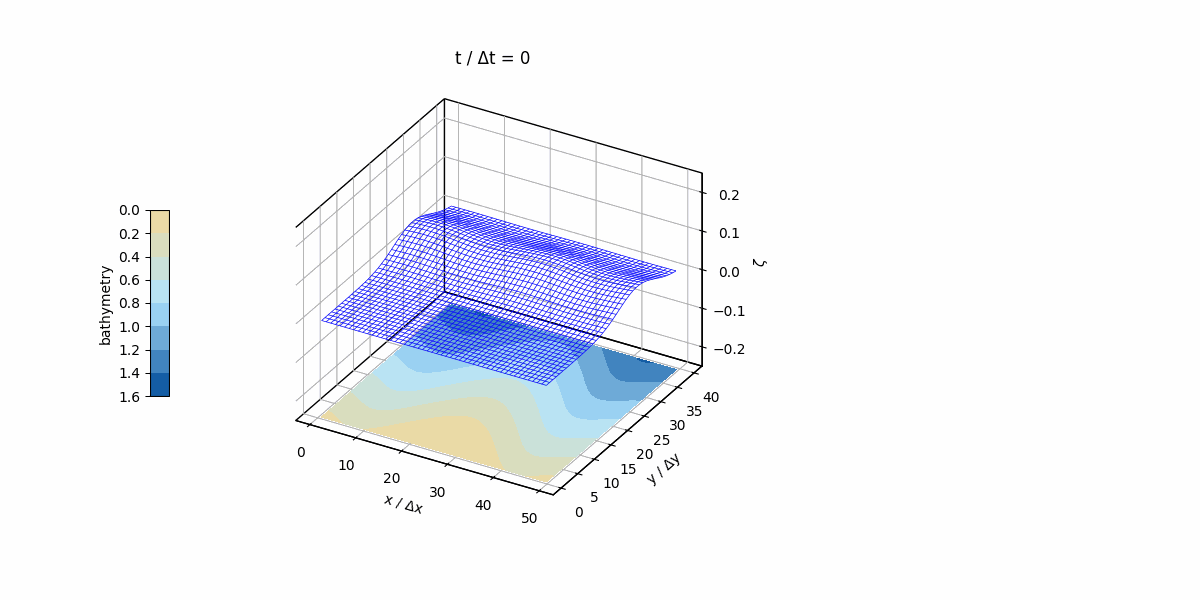

HTML(value="<a href='.\\tmpwlpgkqr8.gif' target='_blank'>.\\tmpwlpgkqr8.gif</a><br>")

In [7]:
show_anim(plot, range(len(output['h'])))


In [8]:
# === SIATKA ===
grid = (50, 40)
nx, ny = grid
# ---------------------------------------
# 2D BATYMETRIA Z RIP CURRENT
# ---------------------------------------
# x – od oceanu (0) do brzegu (1)
x = np.linspace(0, 1, ny)
# y – wzdłuż brzegu
y = np.linspace(-1, 1, nx)
X, Y = np.meshgrid(x, y)
# bazowy stok plaży (głębiej po lewej, płyciej przy brzegu)
slope = 0.03
base = 0.1 + slope * (x * ny)
base = np.tile(base, (nx, 1))
# kanał ripowy (głębszy środek wzdłuż brzegu)
channel = -0.25 * np.exp(-(Y**2) / 0.15)
# łachy piasku po bokach
bars = (
    0.12 * np.exp(-((Y - 0.7)**2) / 0.06) +
    0.12 * np.exp(-((Y + 0.7)**2) / 0.06)
)
# finalna batymetria
bathymetry = base + channel + bars
bathymetry = np.maximum(bathymetry, 0.05)
# ---------------------------------------
# POCZĄTKOWA FALA NA CAŁEJ SZEROKOŚCI
# ---------------------------------------
# fale mają pochodzić z lewej (oceanu)
amplitude = 0.05
# x0 = 0.9     # środek fali – dalej w oceanie
# width = 0.12 # szeroka fala
x0 = 0.7
width = 0.2
wave = amplitude * np.exp(-((x - x0)**2) / width**2)
# modulacja = nieregularność wzdłuż brzegu
modulation = 1 + 0.1 * np.cos(2*np.pi * (y[:,None] + np.random.rand()))
wave2d = wave[None, :] * modulation
h_initial = bathymetry + wave2d
# ---------------------------------------
# SYMULACJA
# ---------------------------------------
output = ShallowWaterEquationsIntegrator(h_initial=h_initial)(
    nt=400,
    g=10,
    dt_over_dxy=(0.15, 0.15),
    outfreq=4
)



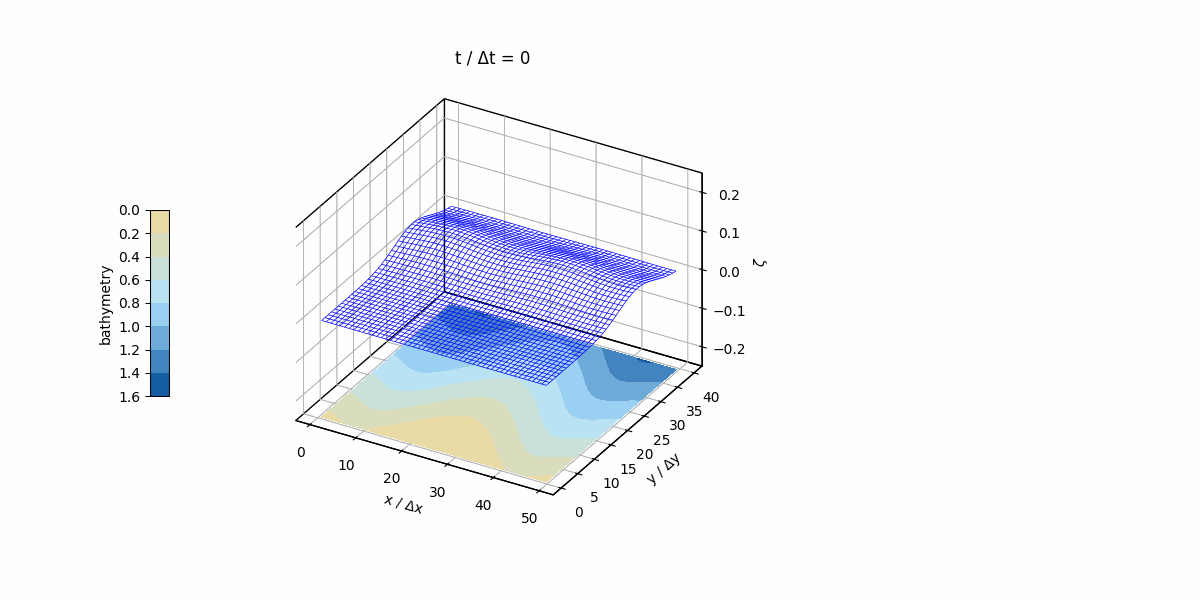

HTML(value="<a href='.\\tmpas08zrjc.gif' target='_blank'>.\\tmpas08zrjc.gif</a><br>")

In [9]:
show_anim(plot, range(len(output['h'])))
